<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/01_intro_and_tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Learning Notes

**Ali Hamza**
🔗 [linkedin.com/in/alihamzastudent](https://www.linkedin.com/in/alihamzastudent/)

---
Notes from Lecture 1 (Introduction to PyTorch) and Lecture 2 (Tensors), organized with explanations, code, and diagrams for revision.


## 1. Introduction to PyTorch

**PyTorch** is an open-source deep learning framework built by Meta AI. It is widely used because:
- It works with **tensors**, which are the core data structure for all computations (similar to NumPy arrays, but with GPU support).
- It supports **automatic differentiation** (autograd), which is essential for training neural networks.
- It can run computations on a **GPU**, making training much faster than on a CPU alone.

The first step in any PyTorch project is importing the library and confirming the GPU is available, since deep learning models train much faster on GPU.


In [1]:
import torch
print(torch.__version__)

2.11.0+cpu


**Checking GPU availability** — this tells us whether PyTorch can use CUDA (GPU) instead of the CPU.

In [2]:
if torch.cuda.is_available():
    print("GPU is available!")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available. Using CPU.")

GPU not available. Using CPU.


## 2. Tensors

A **tensor** is the fundamental building block in PyTorch — a container for numbers that can have any number of dimensions (0-D scalar, 1-D vector, 2-D matrix, or higher). All model inputs, weights, and outputs in PyTorch are tensors.

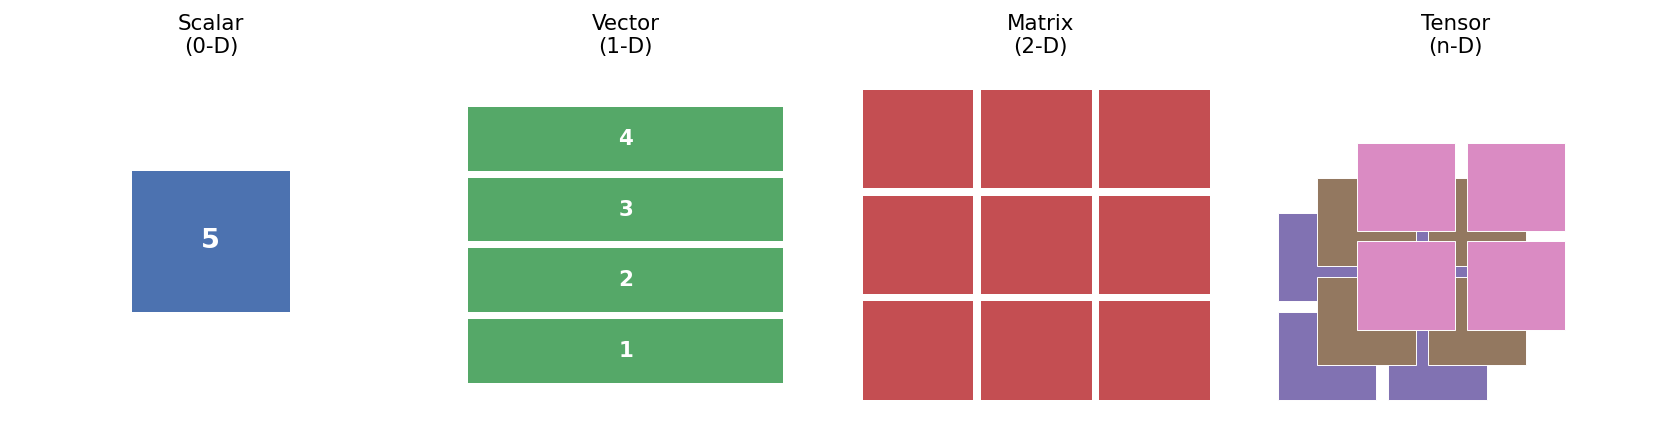


### Creating a Tensor

There are several ways to create a tensor:
- **`torch.empty()`** — allocates memory without initializing values (contains garbage values).
- **`torch.zeros()` / `torch.ones()`** — filled with 0s or 1s.
- **`torch.rand()`** — random values between 0 and 1.
- **`torch.tensor()`** — create a tensor directly from a Python list.
- **`torch.arange()` / `torch.linspace()` / `torch.eye()`** — other useful tensor constructors.


In [3]:
torch.empty(2,3)

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [4]:
# using empty
a = torch.empty(2,3)

In [5]:
# check type
type(a)

torch.Tensor

In [6]:
# using zeros
torch.zeros(2,3)

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [7]:
# using ones
torch.ones(2,3)

tensor([[1., 1., 1.],
        [1., 1., 1.]])

**Random tensors and seeding** — `torch.rand()` gives different values every time it's called. Using `torch.manual_seed()` makes the random values **reproducible**, so the same code always produces the same output — important for debugging and comparing experiments.

In [8]:
# using randam values Random tensor
torch.rand(2,3)

tensor([[0.5174, 0.9859, 0.8268],
        [0.4392, 0.8394, 0.7393]])

In [9]:
# use of seed
torch.rand(2,3)

tensor([[0.4851, 0.7027, 0.6400],
        [0.9853, 0.9841, 0.4447]])

In [10]:
# manual_seed
torch.manual_seed(100)
torch.rand(2,3)

tensor([[0.1117, 0.8158, 0.2626],
        [0.4839, 0.6765, 0.7539]])

In [11]:
torch.manual_seed(100)
torch.rand(2,3)

tensor([[0.1117, 0.8158, 0.2626],
        [0.4839, 0.6765, 0.7539]])

**Creating a tensor from data** — `torch.tensor()` converts a Python list (or nested list) directly into a tensor.

In [12]:
# using tensor
torch.tensor([[1,2,3],
              [4,5,6],
              [3,4,5]])

tensor([[1, 2, 3],
        [4, 5, 6],
        [3, 4, 5]])

**Other useful constructors:**
- `torch.arange(start, end, step)` — evenly spaced values with a fixed step.
- `torch.linspace(start, end, steps)` — a fixed *number* of evenly spaced values.
- `torch.eye(n)` — an identity matrix of size n×n.

In [13]:
# other ways

# arange
print("using arange ->", torch.arange(0,10,2))

# using linspace
print("using linspace ->", torch.linspace(0,10,10))

# using eye
print("using eye ->", torch.eye(5))

using arange -> tensor([0, 2, 4, 6, 8])
using linspace -> tensor([ 0.0000,  1.1111,  2.2222,  3.3333,  4.4444,  5.5556,  6.6667,  7.7778,
         8.8889, 10.0000])
using eye -> tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])


### Tensor Shapes

Every tensor has a **shape** — the size of each dimension. Knowing the shape is critical for debugging model errors (most PyTorch bugs are shape-mismatch errors).

The `_like` functions (`empty_like`, `zeros_like`, `ones_like`, `rand_like`) create a new tensor with the **same shape** as an existing tensor — very useful when you need a placeholder tensor matching another tensor's dimensions.


In [14]:
x = torch.tensor([[1,2,3],[4,5,6]])
x

tensor([[1, 2, 3],
        [4, 5, 6]])

In [15]:
x.shape

torch.Size([2, 3])

In [16]:
torch.empty_like(x)

tensor([[137499958070672,       327921856,       327940720],
        [      225986080,               0,       319358080]])

In [17]:
torch.zeros_like(x)

tensor([[0, 0, 0],
        [0, 0, 0]])

In [18]:
torch.ones_like(x)

tensor([[1, 1, 1],
        [1, 1, 1]])

In [19]:
torch.rand_like(x, dtype=torch.float32)

tensor([[0.2627, 0.0428, 0.2080],
        [0.1180, 0.1217, 0.7356]])

### Tensor Data Types

Every tensor has a **`dtype`** — the type of numbers it stores (integers, floats, booleans, etc.). Choosing the right dtype matters for memory usage and precision:
- `torch.float32` is the default and most commonly used for training neural networks.
- Integer types (`int32`, `int64`) are used for indexing and labels.
- `.to(dtype)` converts a tensor to a different dtype.


In [20]:
# find data type
x.dtype

torch.int64

In [21]:
# assign data type
torch.tensor([1.0,2.0,3.0], dtype=torch.int32)

tensor([1, 2, 3], dtype=torch.int32)

In [22]:
torch.tensor([1,2,3], dtype=torch.float64)

tensor([1., 2., 3.], dtype=torch.float64)

In [23]:
# using to()
x.to(torch.float32)

tensor([[1., 2., 3.],
        [4., 5., 6.]])

**Reference — common PyTorch dtypes:**

| Data Type | Dtype | Description |
|---|---|---|
| 32-bit Floating Point | `torch.float32` | Standard floating-point type used for most deep learning tasks. Balance of precision and memory. |
| 64-bit Floating Point | `torch.float64` | Double precision. Used for high-precision numerical tasks, uses more memory. |
| 16-bit Floating Point | `torch.float16` | Half precision. Common in mixed-precision training to reduce memory/compute on modern GPUs. |
| BFloat16 | `torch.bfloat16` | Brain floating-point format with reduced precision compared to float16. Used in mixed-precision training, especially on TPUs. |
| 8-bit Floating Point | `torch.float8` | Ultra-low precision. Used in experimental / extreme memory-constrained environments. |
| 8-bit Integer | `torch.int8` | Signed integer. Used in quantized models to save memory/computation at inference. |
| 16-bit Integer | `torch.int16` | Useful for special numerical tasks requiring intermediate precision. |
| 32-bit Integer | `torch.int32` | Standard signed integer. Used for indexing and general-purpose numerical tasks. |
| 64-bit Integer | `torch.int64` | Long integer. Used for large indexing arrays or tasks with large numbers. |
| 8-bit Unsigned Integer | `torch.uint8` | Used for image data (e.g., pixel values between 0 and 255). |
| Boolean | `torch.bool` | Stores True or False. Often used for masks in logical operations. |
| Complex 64 | `torch.complex64` | 32-bit real + 32-bit imaginary parts. Used in scientific and signal processing tasks. |
| Complex 128 | `torch.complex128` | 64-bit real + 64-bit imaginary parts. Higher precision but uses more memory. |
| Quantized Integer | `torch.qint8` | Quantized signed 8-bit integer. Used in quantized models for efficient inference. |
| Quantized Unsigned Integer | `torch.quint8` | Quantized unsigned 8-bit integer. Often used for quantized tensors in image-related tasks. |


## 3. Mathematical Operations

PyTorch tensors support the same arithmetic you'd expect from NumPy, split here into scalar operations, element-wise operations, reductions, matrix operations, and comparisons.


### 1. Scalar Operation

A **scalar operation** applies a single number to every element of a tensor (broadcasting).

In [24]:
x = torch.rand(2,2)
x

tensor([[0.7118, 0.7876],
        [0.4183, 0.9014]])

In [25]:
# addition
x + 2
# substraction
x - 2
# multiplication
x * 3
# division
x / 3
# int division
(x * 100)//3
# mod
((x * 100)//3)%2
# power
x**2

tensor([[0.5066, 0.6203],
        [0.1750, 0.8125]])

### 2. Element-wise Operation

**Element-wise operations** combine two tensors of the same shape, operating position by position.

In [26]:
a = torch.rand(2,3)
b = torch.rand(2,3)

print(a)
print(b)

tensor([[0.9969, 0.7565, 0.2239],
        [0.3023, 0.1784, 0.8238]])
tensor([[0.5557, 0.9770, 0.4440],
        [0.9478, 0.7445, 0.4892]])


In [27]:
# add
a + b

tensor([[1.5526, 1.7335, 0.6679],
        [1.2502, 0.9229, 1.3130]])

In [28]:
# sub
a - b

tensor([[ 0.4411, -0.2205, -0.2201],
        [-0.6455, -0.5661,  0.3346]])

In [29]:
# multiply
a * b

tensor([[0.5540, 0.7391, 0.0994],
        [0.2866, 0.1328, 0.4030]])

In [30]:
# division
a / b

tensor([[1.7938, 0.7743, 0.5042],
        [0.3190, 0.2397, 1.6841]])

In [31]:
# power
a ** b

tensor([[0.9983, 0.7614, 0.5145],
        [0.3218, 0.2771, 0.9096]])

In [32]:
# mod
a % b

tensor([[0.4411, 0.7565, 0.2239],
        [0.3023, 0.1784, 0.3346]])

In [33]:
c = torch.tensor([1, -2, 3, -4])

In [34]:
# abs
torch.abs(c)

tensor([1, 2, 3, 4])

### 3. Reduction Operation

**Reduction operations** collapse a tensor into fewer values — e.g. summing, averaging, or finding the min/max — optionally along a specific dimension (`dim=0` = columns, `dim=1` = rows).

In [35]:
e = torch.randint(size=(2,3), low=0, high=10, dtype=torch.float32)
e

tensor([[8., 0., 7.],
        [0., 0., 9.]])

In [36]:
# sum
torch.sum(e)
# sum along columns
torch.sum(e, dim=0)
# sum along rows
torch.sum(e, dim=1)

tensor([15.,  9.])

In [37]:
# mean
torch.mean(e)
# mean along col
torch.mean(e, dim=0)

tensor([4., 0., 8.])

In [38]:
# median
torch.median(e)

tensor(0.)

In [39]:
# max and min
torch.max(e)
torch.min(e)

tensor(0.)

In [40]:
# product
torch.prod(e)

tensor(0.)

In [41]:
# standard deviation
torch.std(e)

tensor(4.4272)

In [42]:
# variance
torch.var(e)

tensor(19.6000)

In [43]:
# argmax
torch.argmax(e)

tensor(5)

In [44]:
# argmin
torch.argmin(e)

tensor(1)

### 4. Matrix Operations

Matrix operations work on 2-D tensors specifically — matrix multiplication, dot product, transpose, determinant, and inverse. Note: for `matmul(F, G)`, the **inner dimensions must match** (F is 2×3, G is 3×2 → result is 2×2).

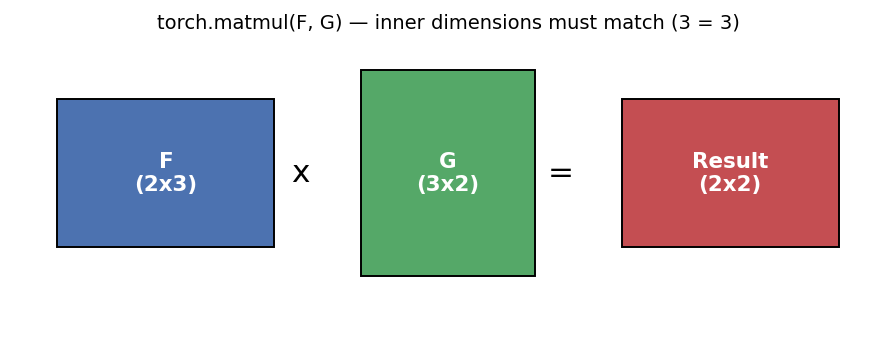


In [45]:
f = torch.randint(size=(2,3), low=0, high=10)
g = torch.randint(size=(3,2), low=0, high=10)

print(f)
print(g)

tensor([[5, 7, 3],
        [9, 4, 0]])
tensor([[5, 7],
        [5, 9],
        [9, 7]])


In [46]:
# matrix multiplication
torch.matmul(f, g)

tensor([[ 87, 119],
        [ 65,  99]])

In [47]:
vector1 = torch.tensor([1, 2])
vector2 = torch.tensor([3, 4])

# dot product
torch.dot(vector1, vector2)

tensor(11)

In [48]:
# transpose
torch.transpose(f, 0, 1)

tensor([[5, 9],
        [7, 4],
        [3, 0]])

In [49]:
h = torch.randint(size=(3,3), low=0, high=10, dtype=torch.float32)
h

tensor([[5., 9., 8.],
        [9., 7., 9.],
        [2., 6., 7.]])

In [50]:
# determinant
torch.det(h)

tensor(-110.)

In [51]:
# inverse
torch.inverse(h)

tensor([[ 0.0455,  0.1364, -0.2273],
        [ 0.4091, -0.1727, -0.2455],
        [-0.3636,  0.1091,  0.4182]])

### 5. Comparison Operations

Comparison operations compare two tensors element-wise and return a **boolean tensor** (`True`/`False` at each position).

In [52]:
i = torch.randint(size=(2,3), low=0, high=10)
j = torch.randint(size=(2,3), low=0, high=10)

print(i)
print(j)

tensor([[7, 8, 3],
        [6, 1, 5]])
tensor([[5, 0, 4],
        [3, 8, 8]])


In [53]:
# greater than
i > j
# less than
i < j
# equal to
i == j
# greater than or equal to
i >= j
# less than or equal to
i <= j
# not equal to
i != j

tensor([[True, True, True],
        [True, True, True]])

## 4. Inplace Operations

Normally, an operation like `m.relu()` returns a **new** tensor and leaves `m` unchanged. An **inplace operation** (marked with a trailing underscore `_`, e.g. `add_()`, `relu_()`) modifies the original tensor **directly**, without creating a new one — this saves memory but should be used carefully since it overwrites the original data.

In [54]:
m = torch.rand(2,3)
n = torch.rand(2,3)

print(m)
print(n)

tensor([[0.6179, 0.3379, 0.2170],
        [0.9454, 0.7116, 0.1157]])
tensor([[0.6574, 0.3451, 0.0453],
        [0.9798, 0.5548, 0.6868]])


In [55]:
m.add_(n)

tensor([[1.2752, 0.6830, 0.2624],
        [1.9251, 1.2663, 0.8025]])

In [56]:
m

tensor([[1.2752, 0.6830, 0.2624],
        [1.9251, 1.2663, 0.8025]])

In [57]:
n

tensor([[0.6574, 0.3451, 0.0453],
        [0.9798, 0.5548, 0.6868]])

In [58]:
torch.relu(m)

tensor([[1.2752, 0.6830, 0.2624],
        [1.9251, 1.2663, 0.8025]])

In [59]:
m.relu_()
# _ underscore laga doo then it is implace operations

tensor([[1.2752, 0.6830, 0.2624],
        [1.9251, 1.2663, 0.8025]])

In [60]:
m

tensor([[1.2752, 0.6830, 0.2624],
        [1.9251, 1.2663, 0.8025]])

## 5. Copying a Tensor

**Important gotcha:** writing `b = a` does **not** create a real copy — `b` just points to the same memory as `a`. Changing `a` will also change `b`. To create an independent copy, use **`a.clone()`** instead.

In [61]:
a = torch.rand(2,3)
a

tensor([[0.4920, 0.0748, 0.9605],
        [0.3271, 0.0103, 0.9516]])

In [62]:
b = a

In [63]:
b

tensor([[0.4920, 0.0748, 0.9605],
        [0.3271, 0.0103, 0.9516]])

In [64]:
a[0][0] = 0

In [65]:
# notice b changed too, because b and a share the same memory
print(a)
print(b)

tensor([[0.0000, 0.0748, 0.9605],
        [0.3271, 0.0103, 0.9516]])
tensor([[0.0000, 0.0748, 0.9605],
        [0.3271, 0.0103, 0.9516]])


In [66]:
# use clone() to get an independent copy
b = a.clone()
a[0][1] = 99
print(a)
print(b)

tensor([[0.0000e+00, 9.9000e+01, 9.6049e-01],
        [3.2709e-01, 1.0255e-02, 9.5160e-01]])
tensor([[0.0000, 0.0748, 0.9605],
        [0.3271, 0.0103, 0.9516]])


## 6. Indexing & Slicing

Just like NumPy arrays, tensors support **indexing** (picking a single element/row/column) and **slicing** (picking a range). This is used constantly — e.g. selecting a batch, a specific feature column, or a sub-region of an image tensor.

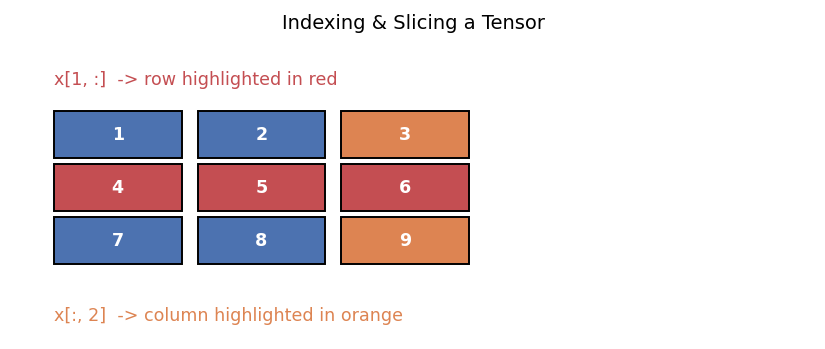


In [67]:
x = torch.tensor([[1,2,3],
                   [4,5,6],
                   [7,8,9]])
x

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [68]:
# select a single row
x[1]

tensor([4, 5, 6])

In [69]:
# select a single column
x[:, 2]

tensor([3, 6, 9])

In [70]:
# select a single element
x[1, 2]

tensor(6)

In [71]:
# slicing: first two rows
x[0:2]

tensor([[1, 2, 3],
        [4, 5, 6]])

In [72]:
# slicing: last two columns
x[:, 1:3]

tensor([[2, 3],
        [5, 6],
        [8, 9]])

In [73]:
# every alternate row
x[::2]

tensor([[1, 2, 3],
        [7, 8, 9]])

## 7. Reshaping Tensors

Reshaping changes a tensor's **shape without changing its data**. This is essential before feeding data into a model (e.g. flattening an image before a linear layer).

- **`reshape()`** — most flexible, works even if the tensor isn't stored contiguously in memory.
- **`view()`** — similar to reshape, but requires the tensor to be contiguous in memory (faster, no copy).
- **`flatten()`** — collapses a tensor into a single 1-D tensor.
- **`permute()`** — reorders dimensions (commonly used for image tensors: channels-first ↔ channels-last).

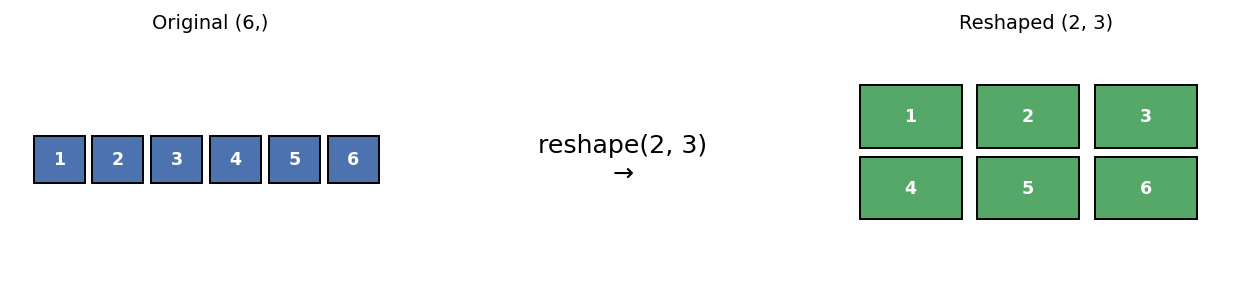


In [74]:
a = torch.arange(1, 7)
a

tensor([1, 2, 3, 4, 5, 6])

In [75]:
# reshape into 2 rows, 3 columns
a.reshape(2, 3)

tensor([[1, 2, 3],
        [4, 5, 6]])

In [76]:
# view() does the same thing (needs contiguous memory)
a.view(2, 3)

tensor([[1, 2, 3],
        [4, 5, 6]])

In [77]:
# reshape with one dimension inferred automatically using -1
a.reshape(3, -1)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [78]:
# flatten back to 1-D
b = a.reshape(2, 3)
b.flatten()

tensor([1, 2, 3, 4, 5, 6])

In [79]:
# permute: swap dimensions (useful for image tensors CxHxW -> HxWxC)
img = torch.rand(3, 4, 5)   # (channels, height, width)
img.permute(1, 2, 0).shape  # -> (height, width, channels)

torch.Size([4, 5, 3])

### Squeeze & Unsqueeze

- **`squeeze()`** removes dimensions of size 1.
- **`unsqueeze()`** adds a dimension of size 1 at a given position — very common when a model expects a **batch dimension** (e.g. turning a single image `(3,224,224)` into a batch of one: `(1,3,224,224)`).

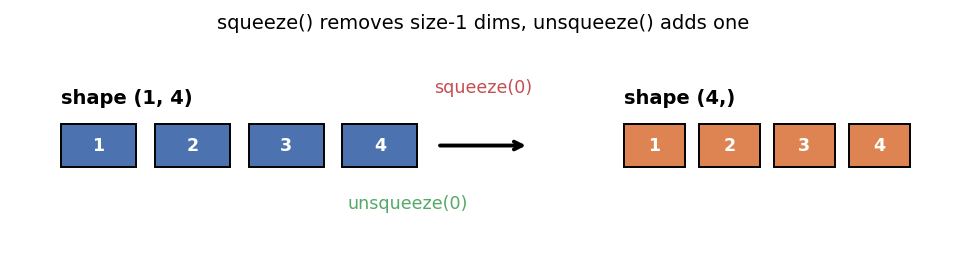


In [80]:
c = torch.rand(1, 4)
c.shape

torch.Size([1, 4])

In [81]:
# squeeze removes the size-1 dimension
c.squeeze(0).shape

torch.Size([4])

In [82]:
d = torch.rand(4)
d.shape

torch.Size([4])

In [83]:
# unsqueeze adds a size-1 dimension (e.g. adding a batch dimension)
d.unsqueeze(0).shape

torch.Size([1, 4])

## 8. Concatenation & Stacking

- **`torch.cat()`** joins tensors along an *existing* dimension (doesn't add a new one).
- **`torch.stack()`** joins tensors along a *new* dimension (e.g. combining several images into a batch).

In [84]:
p = torch.tensor([[1,2],[3,4]])
q = torch.tensor([[5,6],[7,8]])

In [85]:
# concatenate along rows (dim=0)
torch.cat((p, q), dim=0)

tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])

In [86]:
# concatenate along columns (dim=1)
torch.cat((p, q), dim=1)

tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]])

In [87]:
# stack creates a new dimension
torch.stack((p, q))

tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])

## 9. Broadcasting

**Broadcasting** lets PyTorch perform operations between tensors of *different* shapes by automatically expanding the smaller one — without actually copying data in memory. This is why `x + 2` worked earlier (the scalar `2` was broadcast to match `x`'s shape).

Rule of thumb: shapes are compatible if, comparing from the right, each dimension is either equal or one of them is 1.

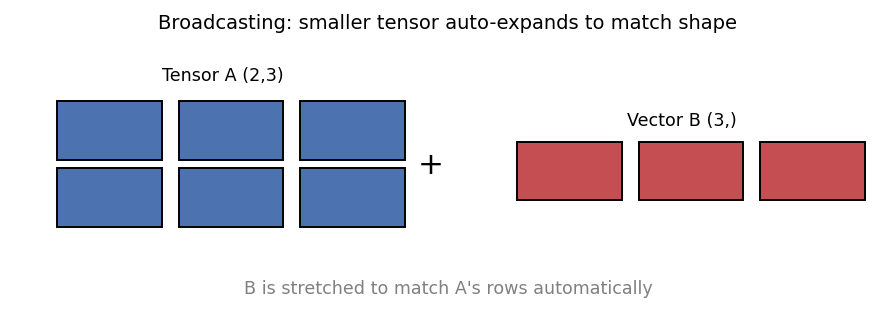


In [88]:
A = torch.tensor([[1,2,3],[4,5,6]])   # shape (2,3)
B = torch.tensor([10,20,30])            # shape (3,)

A + B   # B is broadcast across both rows of A

tensor([[11, 22, 33],
        [14, 25, 36]])

## 10. Converting Between Tensors and NumPy

Since a lot of data preprocessing (pandas, matplotlib, scikit-learn) uses NumPy, PyTorch makes it easy to convert back and forth. **Note:** on CPU, the tensor and NumPy array can share the same memory — changing one changes the other.

In [89]:
import numpy as np

t = torch.tensor([1, 2, 3])

# tensor -> numpy
n = t.numpy()
print(n, type(n))

[1 2 3] <class 'numpy.ndarray'>


In [90]:
# numpy -> tensor
arr = np.array([4, 5, 6])
t2 = torch.from_numpy(arr)
print(t2, type(t2))

tensor([4, 5, 6]) <class 'torch.Tensor'>


## 11. Moving Tensors to GPU

All tensors in an operation must be on the **same device** (CPU or GPU). `.to(device)` moves a tensor to the GPU so computations run much faster during model training.

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [92]:
t = torch.rand(2, 3)
t_gpu = t.to(device)
print(t_gpu.device)

cpu


## 12. Autograd Basics (requires_grad)

PyTorch can automatically compute **gradients** for any tensor operation — this is the foundation of training neural networks (backpropagation). Setting `requires_grad=True` tells PyTorch to track all operations on that tensor so it can compute derivatives later with `.backward()`.

In [93]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1   # y = x^2 + 2x + 1

y.backward()   # computes dy/dx
print("dy/dx at x=3:", x.grad)

dy/dx at x=3: tensor(8.)


---
### Summary

- **Tensors** are the core data structure in PyTorch — created with `empty`, `zeros`, `ones`, `rand`, or directly from data via `tensor()`.
- **Shape** and **dtype** define how a tensor is structured and stored.
- **Math operations** range from simple scalar math to full matrix algebra (`matmul`, `det`, `inverse`).
- **Inplace operations** (`_` suffix) modify a tensor directly to save memory.
- Use **`clone()`**, not `=`, when you need an independent copy of a tensor.
- **Indexing/slicing** selects specific rows, columns, or elements.
- **Reshaping** (`reshape`, `view`, `flatten`, `permute`, `squeeze`, `unsqueeze`) changes shape without changing data — critical for feeding data into models.
- **`cat`/`stack`** combine multiple tensors; **broadcasting** lets differently-shaped tensors interact automatically.
- Tensors convert easily to/from **NumPy**, and move between **CPU/GPU** with `.to(device)`.
- **`requires_grad=True`** + **`.backward()`** is the foundation of automatic differentiation — used to train every neural network in PyTorch.

Next step: **Building a simple neural network in PyTorch (nn.Module, loss functions, optimizers).**
